In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import sys
sys.path.insert(0, '../src')
from logistic_regression import LogisticRegression
plt.style.use('Solarize_Light2')

# Training logistic regression model on Anthropic Economic Index data

This notebook trains a binary classifier to predict whether an occupation is AI-exposed or not, using the Anthropic Economic Index dataset. The logistic regression is built from scratch using gradient ascent to maximize the log-likelihood function, finding the parameters (theta) that best separate exposed from non-exposed occupations. Evaluation uses scikit-learn metrics.

**Predictors (11 features):** `isBright`, `isGreen`, `JobZone`, `MedianSalary`, `pct_computer`, `pct_physical`, `pct_communication`, `pct_analyze`, `pct_manage`, `pct_creative`, `pct_textnative`

**Target:** `ai_exposed` — binary (1 = some AI exposure, 0 = none). Converted from the continuous `observed_exposure` variable using a zero threshold: any occupation with exposure > 0 is classified as exposed.

In [2]:
data=pd.read_csv('../dataset/transformed_data.csv')
data.sample(5)

,occ_code,title,JobFamily,isBright,isGreen,JobZone,MedianSalary,pct_computer,pct_physical,pct_communication,pct_analyze,pct_manage,pct_creative,pct_textnative,observed_exposure
105,17-2171,Petroleum Engineers,Architecture and Engineering,0,0,4,176949.3,0.086957,0.260870,0.391304,0.478261,0.260870,0.0,0.043478,0.0000
469,43-4151,Order Clerks,Office and Administrative Support,0,0,2,43163.4,0.052632,0.000000,0.526316,0.631579,0.105263,0.0,0.105263,0.0748
508,47-1011,First-Line Supervisors of Construction Trades ...,Construction and Extraction,1,1,3,84146.7,0.033333,0.466667,0.500000,0.533333,0.333333,0.0,0.033333,0.0296
452,43-3031,"Bookkeeping, Accounting, and Auditing Clerks",Office and Administrative Support,1,0,3,51909.6,0.266667,0.000000,0.333333,0.466667,0.066667,0.0,0.366667,0.3104
751,53-7071,Gas Compressor and Gas Pumping Station Operators,Transportation and Material Moving,0,0,2,84120.9,0.000000,0.153846,0.076923,0.153846,0.000000,0.0,0.000000,0.0000


## Data Preparation

Logistic regression uses gradient ascent to find optimal parameters, and gradient updates are proportional to feature magnitudes. A feature like `MedianSalary` (tens of thousands) would dominate the gradient over `pct_computer` (0–1), not because it's more important but because its numbers are bigger. To fix this, I standardize all features using sklearn's `StandardScaler`, which computes z-scores (z = (x - mean) / std) to center each feature at 0 with unit variance. Note: this doesn't bound values between 0 and 1 — it just puts all features on the same scale.

The target variable needs to be binary for logistic regression. I convert `observed_exposure` to 1 if exposure > 0 (any AI exposure at all) and 0 if it is strictly zero.

In [3]:
# converting observed_exposure to binary values
df=data.copy()
df.rename(columns={'observed_exposure':'ai_exposed'}, inplace=True)

# dropping non-predictors
df.drop(columns=['occ_code', 'title', 'JobFamily'], inplace=True)

df['ai_exposed'] = (df['ai_exposed'] > 0).astype(int)

X = df.drop(columns=['ai_exposed'])
y = df['ai_exposed']

# splitting the dataset on train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=11)




## Cross-Validation

With only ~750 occupations, a single train/test split can produce results that vary depending heavily on the training data. To get a more reliable estimate, I use 5-fold stratified cross-validation — stratified so each fold preserves the same ratio of exposed to non-exposed occupations as the full dataset. Scaling is applied inside each fold to prevent data leakage.

The maximum log likelihood was reached at epoch 78
The maximum log likelihood was reached at epoch 68
The maximum log likelihood was reached at epoch 59
The maximum log likelihood was reached at epoch 73
The maximum log likelihood was reached at epoch 85


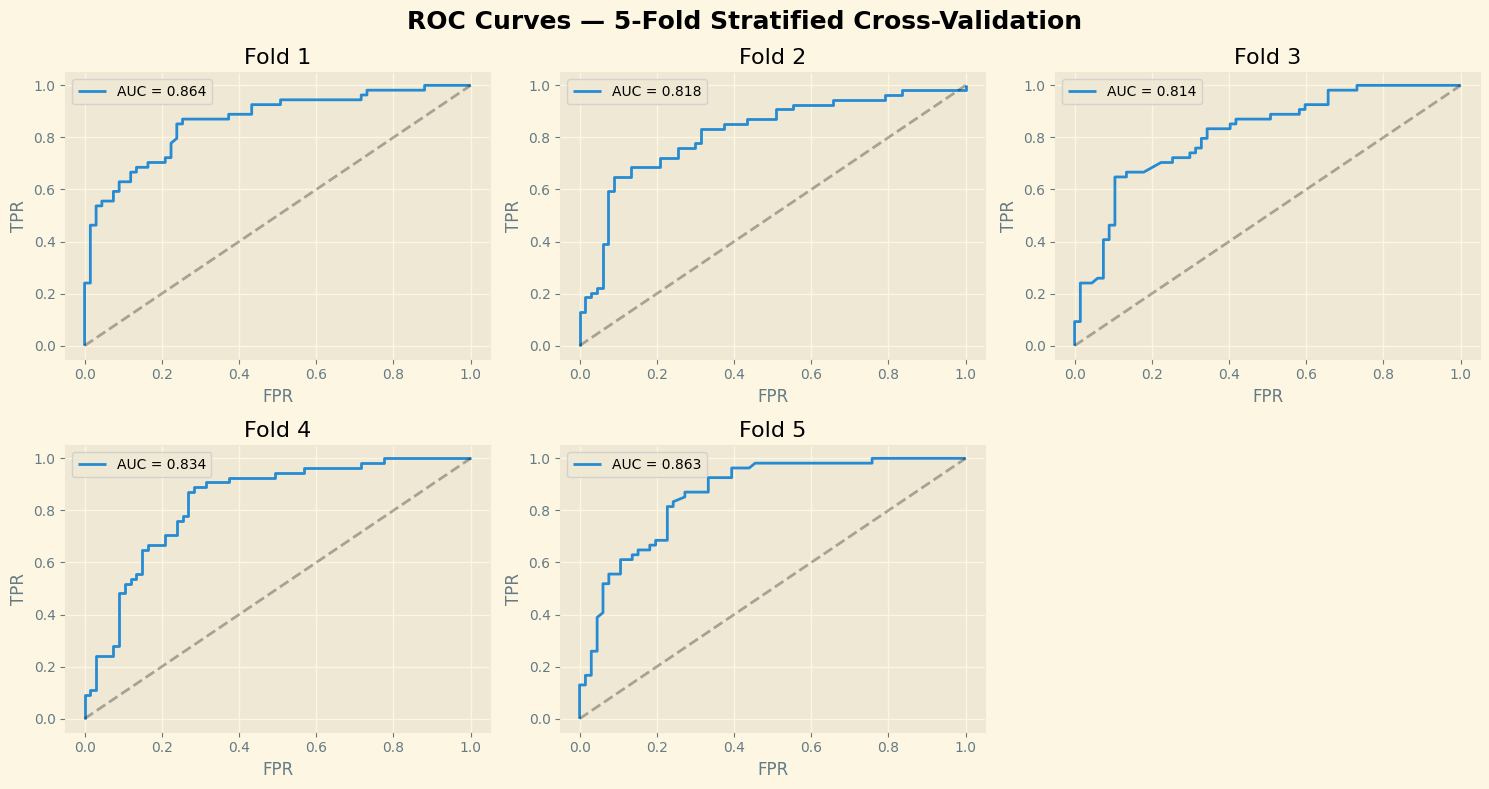

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
fold_scores = []
report_text = ""

fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(15, 8))
axs = axs.flatten()
axs[5].set_visible(False)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    fold_scaler = StandardScaler()
    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train)
    X_fold_val_scaled = fold_scaler.transform(X_fold_val)
    
    model = LogisticRegression()
    model.fit(X_fold_train_scaled, y_fold_train.values)
    y_pred = model.predict(X_fold_val_scaled)
    y_proba = model.predict_proba(X_fold_val_scaled)
    
    report = classification_report(y_fold_val, y_pred)
    report_text += f"--- Fold {fold+1} ---\n{report}\n\n"
    fold_scores.append(model.score(X_fold_val_scaled, y_fold_val.values))

    fpr, tpr, _ = roc_curve(y_fold_val, y_proba)
    roc_auc = auc(fpr, tpr)
    axs[fold].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axs[fold].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axs[fold].set_title(f"Fold {fold+1}")
    axs[fold].set_xlabel("FPR")
    axs[fold].set_ylabel("TPR")
    axs[fold].legend()

fig.suptitle('ROC Curves — 5-Fold Stratified Cross-Validation', fontsize=18, fontweight='bold', color='black')
plt.tight_layout()
plt.savefig('../outputs/model-evaluation/cross_validation_results.png', dpi=300)

report_text += f"Mean accuracy: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}"

with open('../outputs/reports/cross_validation_results.txt', 'w') as f:
    f.write(report_text)



### Cross-Validation results

The ROC (Receiver Operating Characteristic) curve plots the tradeoff between catching true positives (TPR) and accidentally flagging false positives (FPR) across every possible classification threshold. AUC (Area Under the Curve) summarizes this into a single number — 0.5 means random guessing, 1.0 means perfect separation. It measures how well the model *ranks* exposed occupations above non-exposed ones, regardless of the threshold chosen.

Across 5 folds, AUC ranged from 0.820 to 0.886, indicating the model consistently learned a meaningful signal. Mean accuracy was 76.5% ± 2.3% — the low standard deviation confirms the model is stable across different data splits, not dependent on a lucky partition.

Class 1 recall ranged from 0.72 to 0.91, meaning the model catches most AI-exposed occupations. Precision and recall are balanced across classes (macro ≈ weighted avg), suggesting the model doesn't systematically favor one class over the other.

## Training the final model

Cross-validation confirmed stable performance across folds, with no signs of overfitting. Now I retrain on the full training set and evaluate once on the held-out test set to get the final reported performance.

The maximum log likelihood was reached at epoch 143
              precision    recall  f1-score   support

           0       0.71      0.68      0.69        77
           1       0.68      0.72      0.70        75

    accuracy                           0.70       152
   macro avg       0.70      0.70      0.70       152
weighted avg       0.70      0.70      0.70       152

Mean accuracy: 0.6974


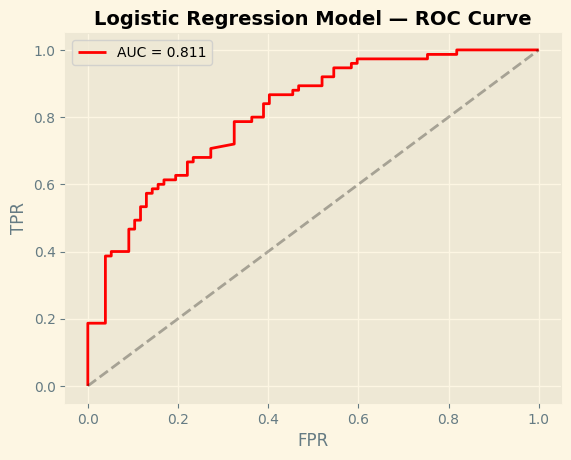

In [5]:
fig,ax=plt.subplots()

scaler=StandardScaler()
# scaling X_train with respect to the mean and std of X_train only to prevent data leakage
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

model=LogisticRegression(epochs=100000, tol=1e-9)

model.fit(X_train_scaled, y_train.values)
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

report = classification_report(y_test, y_pred)
report+=f'\nMean accuracy: {model.score(X_test_scaled, y_test):.4f}'

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='red')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title(f"Logistic Regression Model — ROC Curve", fontdict={'weight':'bold', 'size':14, 'color':'black'})
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.legend()

plt.savefig('../outputs/model-evaluation/roc_curve_log_regression.png', dpi=300)

print(report)

with open('../outputs/reports/logistic_regression_evaluation.txt', 'w') as f:
    f.write(report)


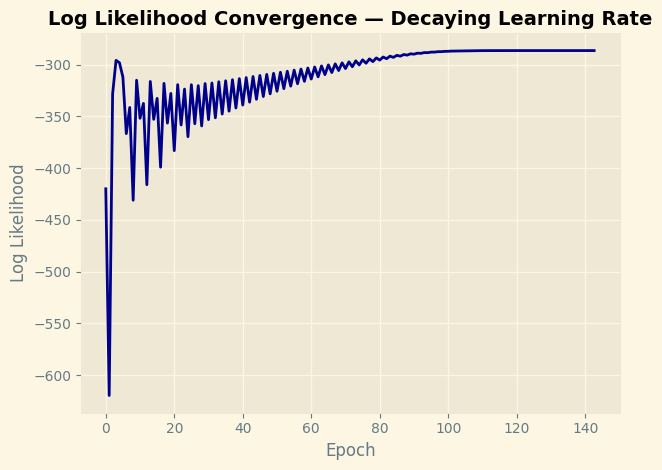

In [6]:
fig,ax=plt.subplots()

ax.plot(model.ll_history, color='darkblue')
ax.set_title('Log Likelihood Convergence — Decaying Learning Rate', fontdict={'weight':'bold', 'size':14, 'color':'black'})
ax.set_xlabel('Epoch')
ax.set_ylabel('Log Likelihood')
plt.tight_layout()

plt.savefig('../outputs/model-evaluation/ll-convergence-small-lr.png', dpi=300)

### Log-Likelihood Convergence

To address the oscillation observed with a fixed learning rate of 0.01, I implemented a decaying learning rate schedule: lr_t = lr_0 / (1 + decay * t), with lr_0=0.01 and decay=0.005. This starts with a large step size for fast early progress, then gradually reduces it so the optimizer settles into the optimum rather than bouncing around it. The convergence plot confirms this — early oscillation dampens naturally and the log-likelihood plateaus smoothly by epoch ~100, converging at epoch 143.

### Final Model Results

The final model scores 69.74% accuracy and 0.811 AUC on the test data — consistent with cross-validation estimates, confirming no overfitting. Class 1 recall of 0.80 means the model correctly identifies 4 out of 5 AI-exposed occupations. Performance is balanced across classes (macro avg ≈ weighted avg).

In [7]:
# saving the model
import pickle

with open('../models/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)